In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   

In [2]:
df = pd.read_csv('../Data/2025_full_data_cleaned.csv', low_memory=False)

In [3]:
df.isna().sum()/len(df) * 100

caseversion            0.000000
i_f_code               0.000000
event_dt              55.345465
rept_cod               0.000000
mfr_sndr               0.000000
age                    0.000000
sex                    0.000000
e_sub                  0.000000
rept_dt                0.000000
occp_cod               0.000000
occr_country           0.000000
role_cod_drug          0.000000
drugname_drug          0.000000
prod_ai_drug           0.000000
val_vbm_drug           0.000000
route_drug             0.000000
dose_vbm_drug          0.000000
cum_dose_chr_drug      0.000000
cum_dose_unit_drug     0.000000
dechal_drug            0.000000
rechal_drug            0.000000
dose_amt_drug          0.000000
dose_unit_drug         0.000000
dose_form_drug         0.000000
dose_freq_drug         0.000000
pt_reac                0.000000
drug_rec_act_reac      0.000000
outc_cod_outc          0.000000
indi_pt_indi           0.000000
dtype: float64

In [4]:
df.head()

,caseversion,i_f_code,event_dt,rept_cod,mfr_sndr,age,sex,e_sub,rept_dt,occp_cod,...,dechal_drug,rechal_drug,dose_amt_drug,dose_unit_drug,dose_form_drug,dose_freq_drug,pt_reac,drug_rec_act_reac,outc_cod_outc,indi_pt_indi
0,2,F,NaN,EXP,NOVARTIS,53.0,F,Y,20250326,HP,...,-1,0,80.0,MG,SOLUTION FOR INJECTION,QD,"Asthenia, Breast cancer metastatic, Palmar-pla...",Injection Site Pain,OT,Breast Cancer Metastatic
1,3,F,20111201.0,EXP,SANOFI AVENTIS,12.0,M,Y,20250307,MD,...,1,0,20.0,MG/KG,POWDER FOR SOLUTION FOR INFUSION,QOW,"Hepatic fibrosis, Red blood cell sedimentation...",Injection Site Pain,OT,"Glycogen Storage Disease Type Ii, Premedication"
2,3,F,20130901.0,PER,AMGEN,1.0,M,Y,20250226,CN,...,0,0,3.0,ML,SOLUTION FOR INJECTION,QD,"Increased tendency to bruise, Exposure via bre...",Injection Site Pain,Unknown,Maternal Exposure During Breast Feeding
3,22,F,20140204.0,EXP,ROCHE,57.0,M,Y,20250110,CN,...,0,0,225.0,MG,"INJECTION, SOLUTION, SOLUTION FOR INJECTION IN...","Q3W, /MONTH, QD","Dizziness, Dysphonia, Rhinitis allergic, Photo...",Injection Site Pain,HO,"Antibiotic Prophylaxis, Asthma"
4,8,F,20140101.0,PER,PFIZER,69.0,F,Y,20250203,CN,...,0,0,60.0,MG,TABLET,QD,"Hot flush, Feeling abnormal, Abdominal pain up...",Injection Site Pain,Unknown,"Drug Hypersensitivity, Fibromyalgia, Menopausa..."


In [5]:
df.describe()

,caseversion,event_dt,age,rept_dt,dechal_drug,rechal_drug,dose_amt_drug
count,1.581116e+06,7.060400e+05,1.581116e+06,1.581116e+06,1.581116e+06,1.581116e+06,1.581116e+06
mean,1.837951e+00,2.024049e+07,5.463976e+01,2.025067e+07,-4.625486e-01,-4.896282e-01,2.025213e+02
std,2.601943e+00,3.443775e+04,1.815325e+01,7.173704e+03,7.029119e-01,5.089739e-01,1.193449e+04
min,1.000000e+00,1.015031e+07,0.000000e+00,2.000022e+07,-1.000000e+00,-1.000000e+00,0.000000e+00
25%,1.000000e+00,2.024050e+07,5.300000e+01,2.025040e+07,-1.000000e+00,-1.000000e+00,4.000000e+01
50%,1.000000e+00,2.025010e+07,5.463586e+01,2.025070e+07,-1.000000e+00,0.000000e+00,8.000000e+01
75%,2.000000e+00,2.025052e+07,6.400000e+01,2.025093e+07,0.000000e+00,0.000000e+00,1.400000e+02
max,1.510000e+02,2.444110e+07,8.000000e+03,2.925061e+07,1.000000e+00,1.000000e+00,1.200000e+07


In [6]:
df['event_dt'] = pd.to_datetime(df['event_dt'], errors='coerce')

In [7]:
df['event_dt'].nunique()

5499

In [8]:
df.drop(columns=['event_dt'], inplace=True)

In [9]:
df.columns

Index(['caseversion', 'i_f_code', 'rept_cod', 'mfr_sndr', 'age', 'sex',
       'e_sub', 'rept_dt', 'occp_cod', 'occr_country', 'role_cod_drug',
       'drugname_drug', 'prod_ai_drug', 'val_vbm_drug', 'route_drug',
       'dose_vbm_drug', 'cum_dose_chr_drug', 'cum_dose_unit_drug',
       'dechal_drug', 'rechal_drug', 'dose_amt_drug', 'dose_unit_drug',
       'dose_form_drug', 'dose_freq_drug', 'pt_reac', 'drug_rec_act_reac',
       'outc_cod_outc', 'indi_pt_indi'],
      dtype='str')

In [10]:
df['i_f_code']

0          F
1          F
2          F
3          F
4          F
          ..
1581111    F
1581112    F
1581113    F
1581114    F
1581115    F
Name: i_f_code, Length: 1581116, dtype: str

<Axes: xlabel='i_f_code', ylabel='count'>

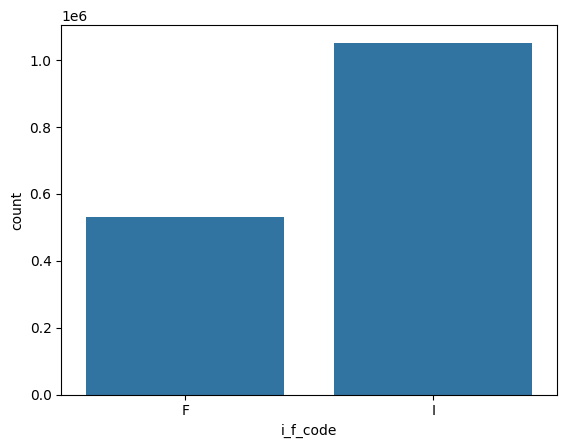

In [11]:
sns.countplot(x='i_f_code', data=df)

<Axes: xlabel='count', ylabel='rept_cod'>

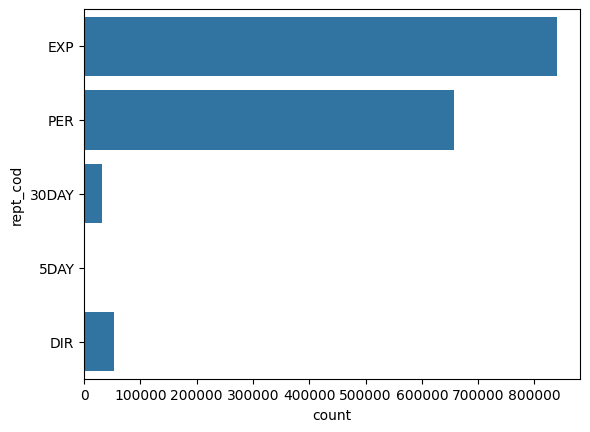

In [12]:
sns.countplot(y='rept_cod', data=df)

<Axes: ylabel='mfr_sndr'>

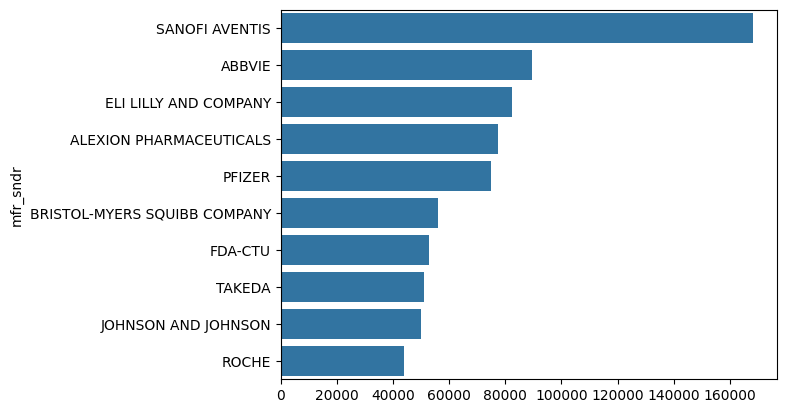

In [13]:
top = df['mfr_sndr'].value_counts().head(10)
sns.barplot(x=top.values, y=top.index)

In [14]:
df['age'].describe()

count    1.581116e+06
mean     5.463976e+01
std      1.815325e+01
min      0.000000e+00
25%      5.300000e+01
50%      5.463586e+01
75%      6.400000e+01
max      8.000000e+03
Name: age, dtype: float64

<Axes: xlabel='age'>

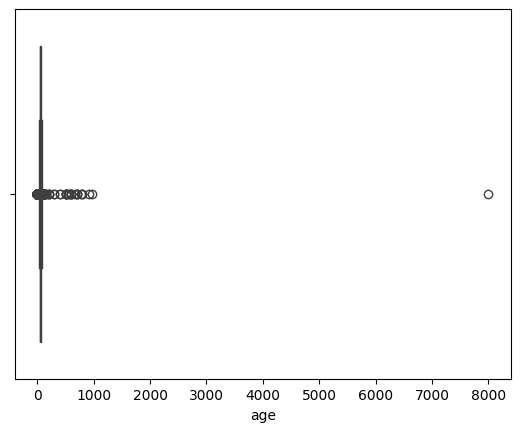

In [15]:
sns.boxplot(x='age', data=df)

In [16]:
df['age'].unique()

array([5.30000000e+01, 1.20000000e+01, 1.00000000e+00, 5.70000000e+01,
       6.90000000e+01, 0.00000000e+00, 2.30000000e+01, 5.46358592e+01,
       1.30000000e+01, 7.40000000e+01, 4.00000000e+01, 6.00000000e+01,
       5.83333333e-01, 7.30000000e+01, 5.80000000e+01, 3.50000000e+01,
       6.40000000e+01, 5.60000000e+01, 7.50000000e+01, 5.50000000e+01,
       7.80000000e+01, 6.20000000e+01, 6.10000000e+01, 7.10000000e+01,
       8.30000000e+01, 5.90000000e+01, 1.00000000e+01, 8.20000000e+01,
       3.40000000e+01, 4.40000000e+01, 6.70000000e+01, 4.90000000e+01,
       3.00000000e+01, 3.70000000e+01, 1.80000000e+01, 2.70000000e+01,
       3.20000000e+01, 3.30000000e+01, 6.50000000e+01, 1.10000000e+01,
       1.60000000e+01, 8.00000000e+00, 6.60000000e+01, 3.60000000e+01,
       4.50000000e+01, 6.30000000e+01, 8.00000000e+01, 2.90000000e+01,
       2.00000000e+00, 7.70000000e+01, 3.90000000e+01, 5.10000000e+01,
       2.00000000e+01, 1.70000000e+01, 4.70000000e+01, 3.10000000e+01,
      

<Axes: xlabel='sex', ylabel='age'>

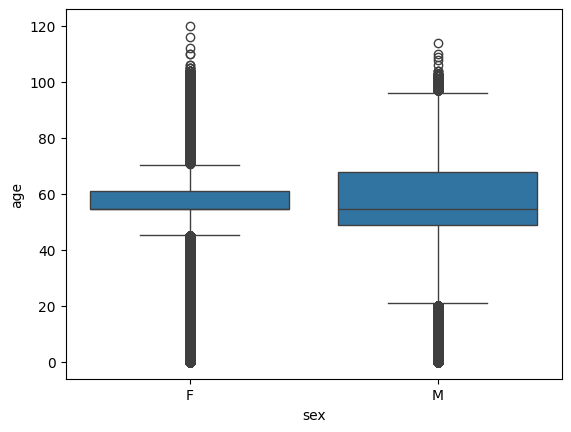

In [17]:

df.loc[((df['age'] < 0) | (df['age'] > 120)), 'age'] = np.nan
median_age = df['age'].median()
df['age'] = df['age'].fillna(median_age)

sns.boxplot(x='sex', y='age', data=df)

<Axes: ylabel='occr_country'>

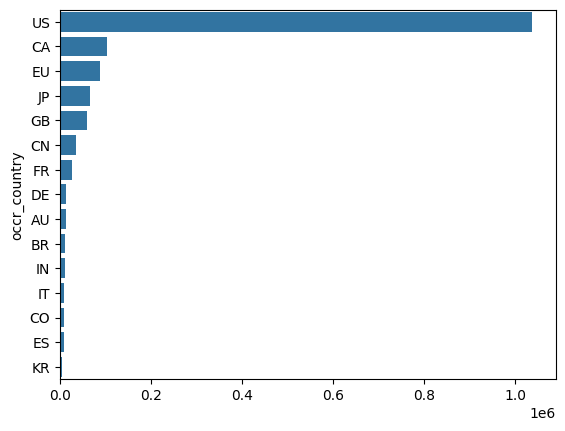

In [18]:
top = df['occr_country'].value_counts().head(15)
sns.barplot(x=top.values, y=top.index)

<Axes: ylabel='drugname_drug'>

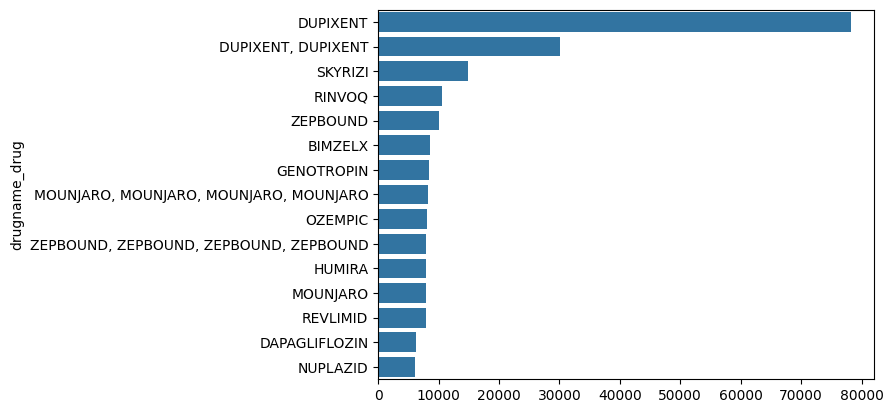

In [19]:
top = df['drugname_drug'].value_counts().head(15)
sns.barplot(x=top.values, y=top.index)

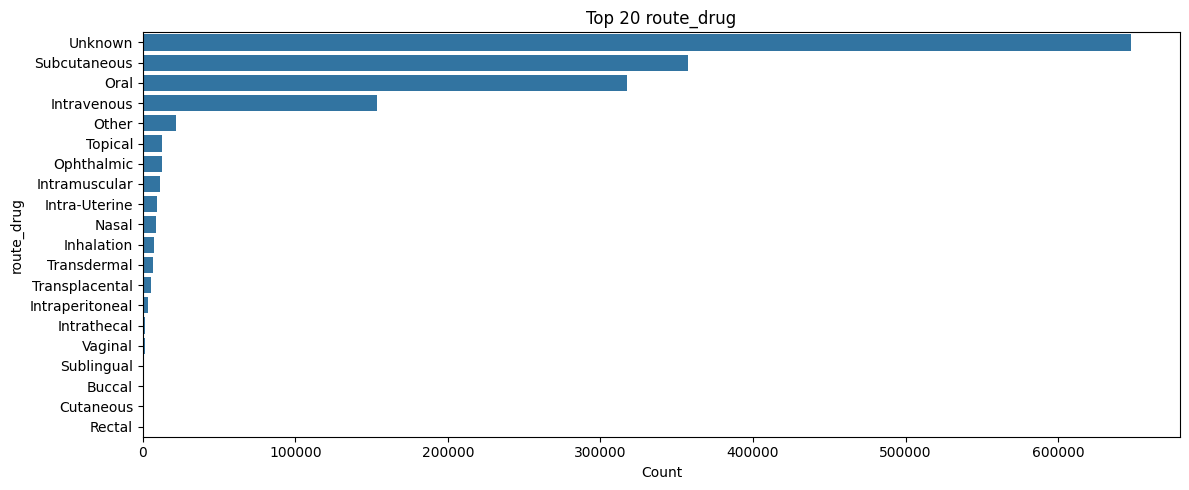

In [20]:
top = df['route_drug'].value_counts(dropna=True).head(20)

plt.figure(figsize=(12, 5))
sns.barplot(x=top.values, y=top.index)
plt.title('Top 20 route_drug')
plt.xlabel('Count')
plt.ylabel('route_drug')
plt.tight_layout()
plt.show()

C:\Users\abdelrahman\AppData\Local\Temp\ipykernel_15008\2119829886.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_forms.values, y=top_forms.index, palette='viridis')


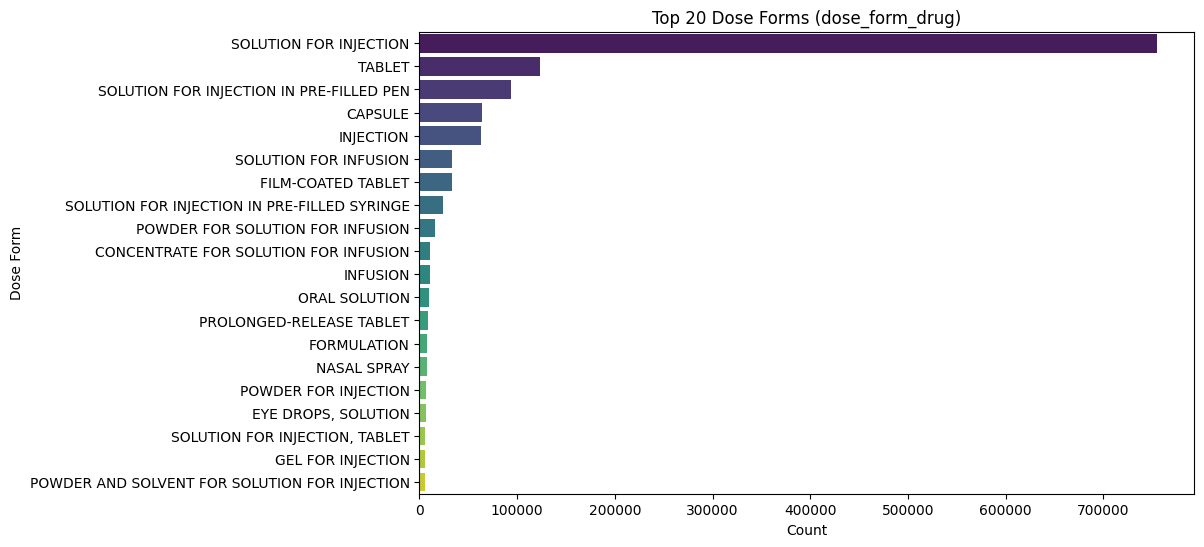

In [21]:

top_forms = df['dose_form_drug'].value_counts().head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_forms.values, y=top_forms.index, palette='viridis')
plt.title('Top 20 Dose Forms (dose_form_drug)')
plt.xlabel('Count')
plt.ylabel('Dose Form')
plt.show()

C:\Users\abdelrahman\AppData\Local\Temp\ipykernel_15008\2925042914.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_freqs.values, y=top_freqs.index, palette='magma')


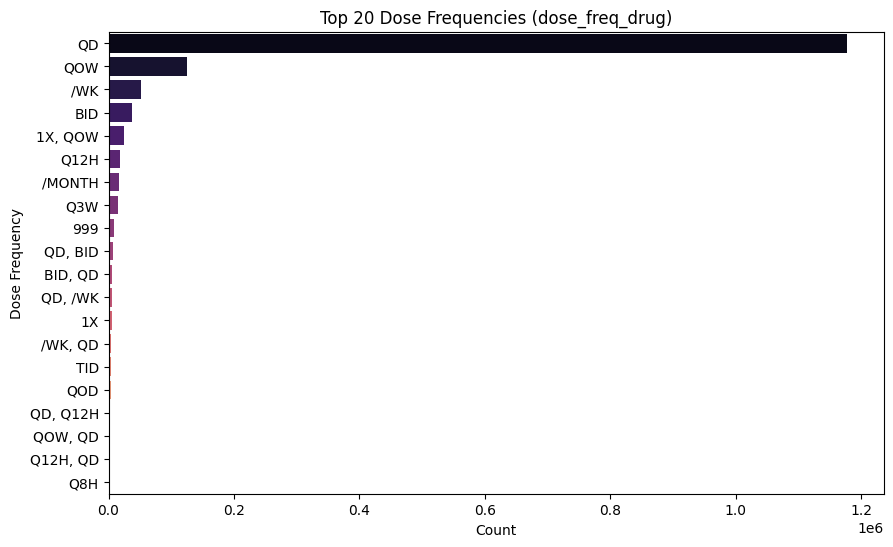

In [22]:
top_freqs = df['dose_freq_drug'].value_counts().head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_freqs.values, y=top_freqs.index, palette='magma')
plt.title('Top 20 Dose Frequencies (dose_freq_drug)')
plt.xlabel('Count')
plt.ylabel('Dose Frequency')
plt.show()

c:\Users\abdelrahman\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


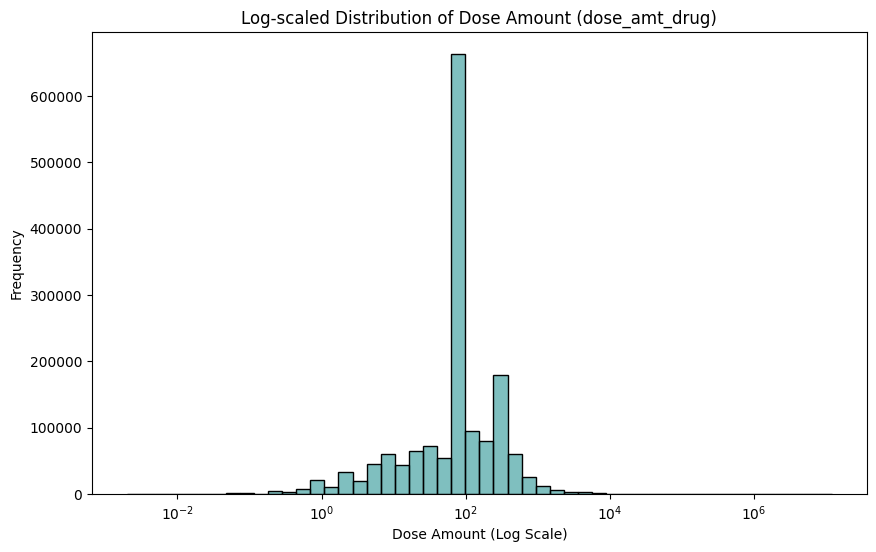

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['dose_amt_drug'], bins=50, kde=True, color='teal', log_scale=True)
plt.title('Log-scaled Distribution of Dose Amount (dose_amt_drug)')
plt.xlabel('Dose Amount (Log Scale)')
plt.ylabel('Frequency')
plt.show()

<Axes: ylabel='pt_reac'>

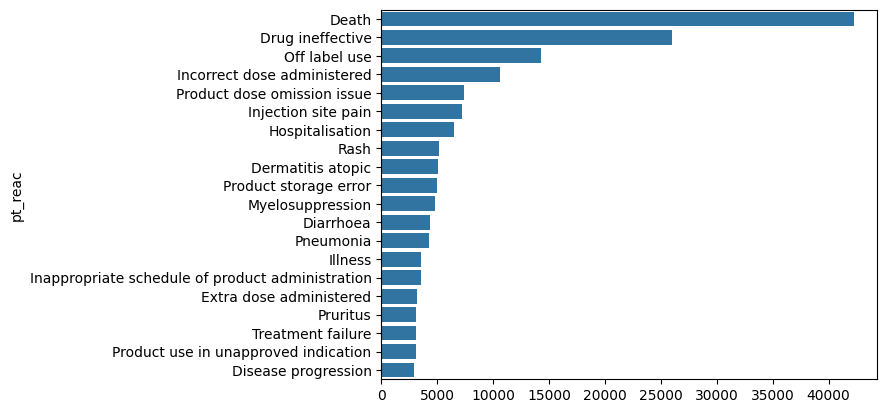

In [27]:
top = df['pt_reac'].value_counts().head(20)
sns.barplot(x=top.values, y=top.index)

C:\Users\abdelrahman\AppData\Local\Temp\ipykernel_15008\3832532497.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_actions.values, y=top_actions.index, palette='viridis')


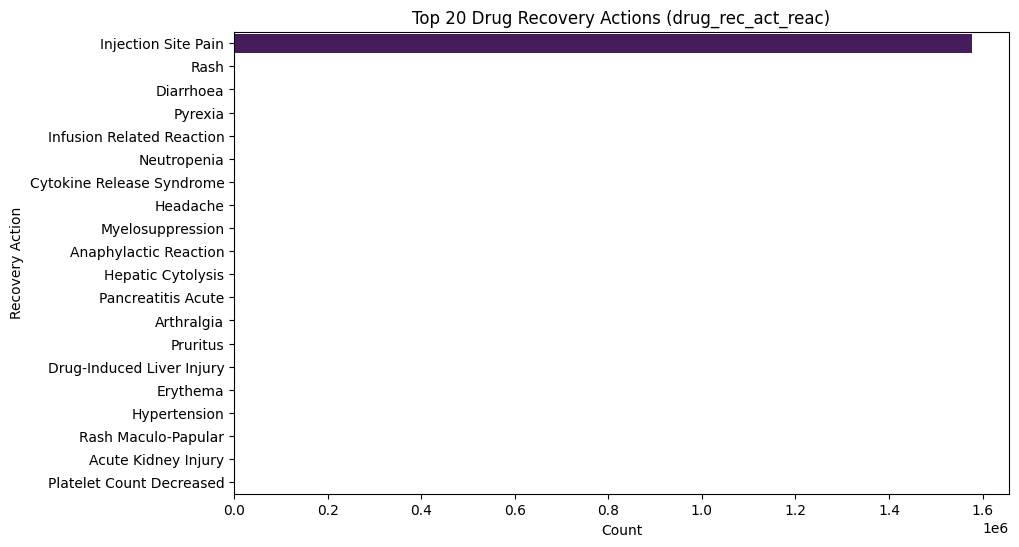

In [28]:
top_actions = df['drug_rec_act_reac'].value_counts().head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_actions.values, y=top_actions.index, palette='viridis')
plt.title('Top 20 Drug Recovery Actions (drug_rec_act_reac)')
plt.xlabel('Count')
plt.ylabel('Recovery Action')
plt.show()

In [30]:
df['drug_rec_act_reac'].value_counts()

drug_rec_act_reac
Injection Site Pain                                               1577805
Rash                                                                   60
Diarrhoea                                                              54
Pyrexia                                                                36
Infusion Related Reaction                                              32
                                                                   ...   
Headache, Decreased Appetite, Neuropathy Peripheral, Dysgeusia          1
Peripheral Swelling, Neuropathy Peripheral                              1
Normochromic Normocytic Anaemia                                         1
Vision Blurred, Toothache, Headache                                     1
Hypoglycaemia                                                           1
Name: count, Length: 1810, dtype: int64

C:\Users\abdelrahman\AppData\Local\Temp\ipykernel_15008\4123776758.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=outc_counts.index, y=outc_counts.values, palette='coolwarm')


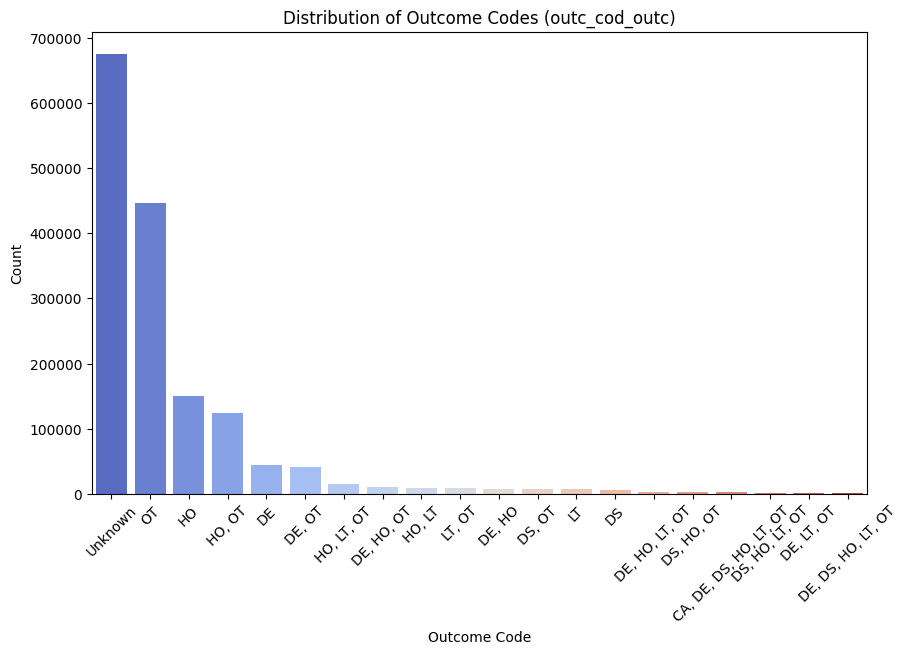

In [32]:
outc_counts = df['outc_cod_outc'].value_counts().head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=outc_counts.index, y=outc_counts.values, palette='coolwarm')
plt.title('Distribution of Outcome Codes (outc_cod_outc)')
plt.xlabel('Outcome Code')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

<Axes: ylabel='indi_pt_indi'>

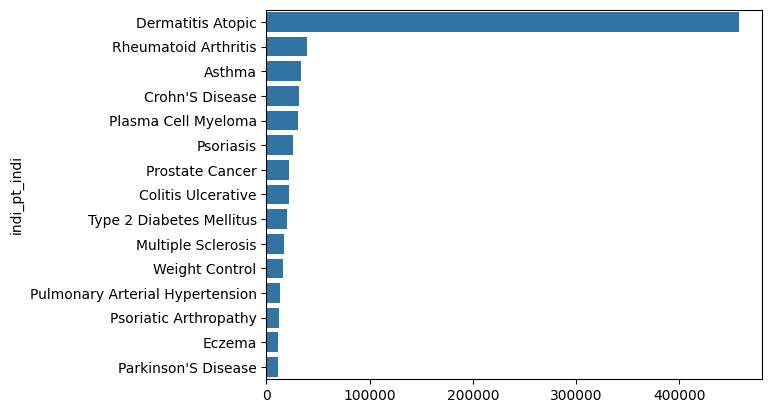

In [33]:
top = df['indi_pt_indi'].value_counts().head(15)
sns.barplot(x=top.values, y=top.index)

<Axes: ylabel='occr_country'>

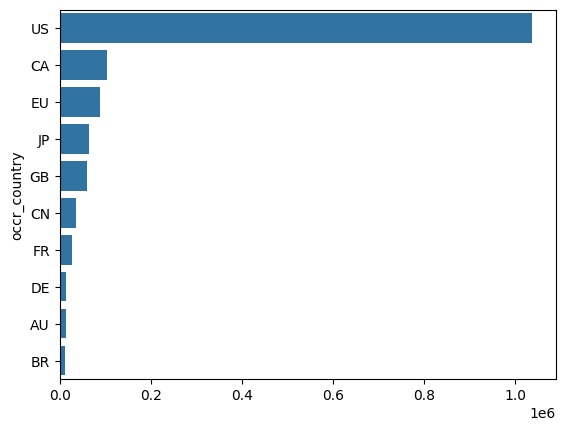

In [35]:
country_counts = df['occr_country'].value_counts().head(10)

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

C:\Users\abdelrahman\AppData\Local\Temp\ipykernel_15008\1459927855.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dechal_counts.index, y=dechal_counts.values, palette='viridis')


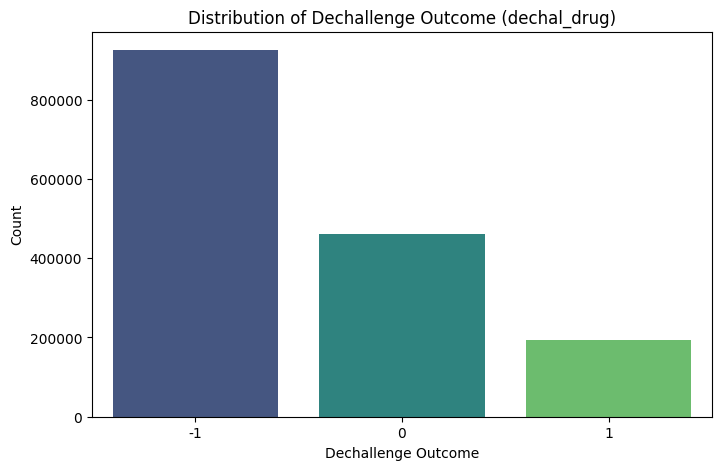

In [39]:
dechal_counts = df['dechal_drug'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=dechal_counts.index, y=dechal_counts.values, palette='viridis')
plt.title('Distribution of Dechallenge Outcome (dechal_drug)')
plt.xlabel('Dechallenge Outcome')
plt.ylabel('Count')
plt.show()